In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.ndimage import gaussian_filter

import fusiproc_utils2 as fu

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# -------- dataset paths -------
BASE = Path("/Users/clairenastaskin/data/sub-Forest001/2026-02-26/deep_individual_digit_069a0d6e-f68d-712b-8000-ca045d6357fa")
RUN  = "pwd.nii.gz"               # raw fUSI volume (change if needed)
PWD  = BASE / RUN

# -------- preprocessing switches ----
REG_REFERENCE = "mean"          # registration reference: {"mean", "median"}

SMOOTH_METHOD = "boxcar"        # temporal smoothing: {"none", "boxcar", "savgol"}
SMOOTH_WINDOW = 3               # for boxcar (odd)
SG_PARAMS     = dict(window=7, polyorder=2)  # for Savitzky–Golay

FD_THRESH  = 0.5                # mm — framewise displacement threshold
RADIUS_MM  = 50.0               # mm — sphere radius for FD

# -------- connectivity-specific switches ----
SPATIAL_SIGMA = 2               # voxels — Gaussian spatial smoothing
HP_CUTOFF_HZ  = 1.0 / 60.0      # high-pass cutoff (Hz)
HP_ORDER      = 5               # Butterworth order

# Tag used in saved filenames
if SMOOTH_METHOD == "none":
    smooth_tag = "_nosmooth"
elif SMOOTH_METHOD == "boxcar":
    smooth_tag = f"_boxcar{SMOOTH_WINDOW}"
elif SMOOTH_METHOD == "savgol":
    smooth_tag = f"_savgol{SG_PARAMS['window']}-{SG_PARAMS['polyorder']}"
else:
    raise ValueError(f"Unknown SMOOTH_METHOD: {SMOOTH_METHOD}")

In [3]:
# Load ARIA logs and compute t_r as the mean inter-frame interval
logs_df = pd.read_parquet(BASE / "logs.parquet")
print(f"Loaded logs.parquet: shape {logs_df.shape}")

volume_timing_ns = float(np.mean(np.diff(logs_df["time_ns"].to_numpy())))
volume_timing_s  = volume_timing_ns / 1e9
t_r = volume_timing_s
np.save(BASE / "t_r.npy", t_r)
print(f"t_r = {t_r:.6f} s")

Loaded logs.parquet: shape (404, 14)
t_r = 1.601613 s


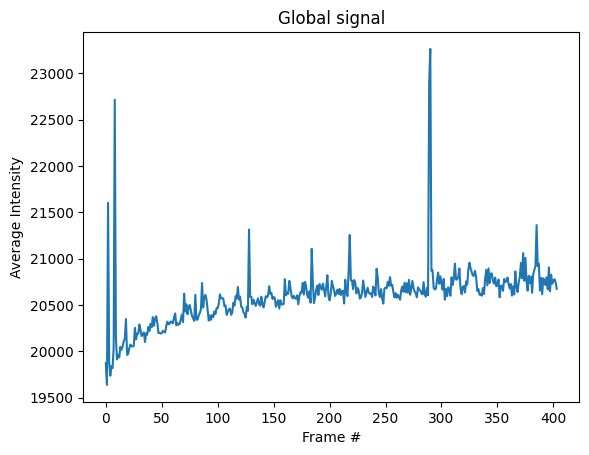

Data shape: (175, 84, 141, 404), mask voxels: 1102145 / 2072700


In [4]:
# Load fUSI data, build NaN-derived brain mask, compute global signal
data, affine, _ = fu.load_fusi_nifti(PWD)
mask = fu.nan_mask(data)
mask_path = fu.save_nifti(mask.astype(np.uint8), affine, BASE / "mask.nii.gz")

gs = fu.global_signal(data)
fu.plot_global_signal(gs, BASE / "global_signal.png", y_lim=None)
print(f"Data shape: {data.shape}, mask voxels: {int(mask.sum())} / {mask.size}")

## Censor high-intensity (motion) frames via the global signal

Drop the first two frames as warm-up, then flag frames whose global signal is
> k σ from the median.

Frames censored after global-signal step: [0, 1, 2, 8, 86, 128, 184, 218, 289, 290, 385]


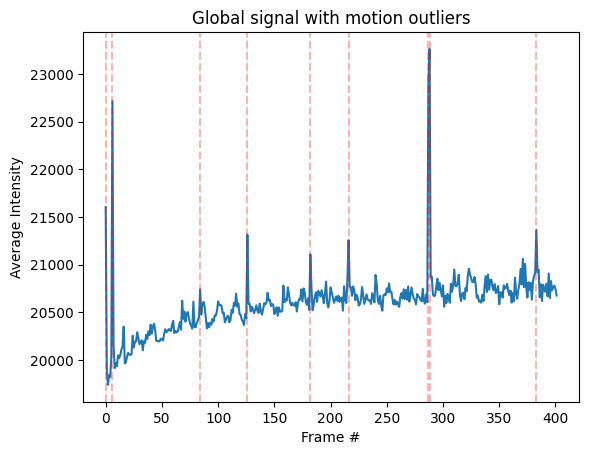

In [5]:
skip = {0, 1}
keep_mask = np.ones(len(gs), dtype=bool)
keep_mask[list(skip)] = False
gs_clean = gs[keep_mask]
kept_frames_gs = np.where(keep_mask)[0]

bad_gs, good_gs, fig = fu.detect_motion_via_global(gs_clean, t_r, k=4.0, y_lim=None)
fig.savefig(BASE / "global_signal_with_masked_frame.png")

# map bad indices back to original frame indices and update skip
skip.update(int(kept_frames_gs[i]) for i in bad_gs)
print(f"Frames censored after global-signal step: {sorted(skip)}")

In [ ]:
## Rigid registration

# Register all kept frames to the chosen reference. Cached on disk in
# `BASE/registration/` — recompute only if the folder is missing.

SyntaxError: invalid syntax (3964320983.py, line 3)

In [7]:
registration_path = BASE / "registration"

if not registration_path.exists():
    registration_path.mkdir(exist_ok=True)
    data_f32 = np.where(np.isfinite(data), data, 0).astype(np.float32, copy=False)

    reg, rigid, metric, stop, kept_idx = fu.register_3d_image_stack(
        data_f32,
        reference=REG_REFERENCE,
        spacing=np.linalg.norm(affine[:3, :3], axis=0),
        skip_indices=skip,
        mask=mask,
        verbose=True,
    )
    del data_f32

    np.save(registration_path / "reg.npy", reg)
    np.save(registration_path / "rigid.npy", rigid)
    np.save(registration_path / "metric.npy", metric)
    np.save(registration_path / "stop.npy", stop)
    np.save(registration_path / "kept_idx.npy", kept_idx)
    np.save(registration_path / "skip.npy", np.array(sorted(skip), dtype=int))
    fu.save_doppler_movie(reg, registration_path / "Doppler_movie_after_rigid_registration.mp4")
else:
    reg      = np.load(registration_path / "reg.npy")
    rigid    = np.load(registration_path / "rigid.npy")
    metric   = np.load(registration_path / "metric.npy")
    stop     = np.load(registration_path / "stop.npy")
    kept_idx = np.load(registration_path / "kept_idx.npy")
print(f"reg shape: {reg.shape}, kept_idx: {len(kept_idx)} frames")

reg shape: (175, 84, 141, 393), kept_idx: 393 frames


## Framewise displacement (FD) censoring

Compute FD on the registered series, drop frames above `FD_THRESH`, then
NaN-pad the registration outputs back to the original number of frames.

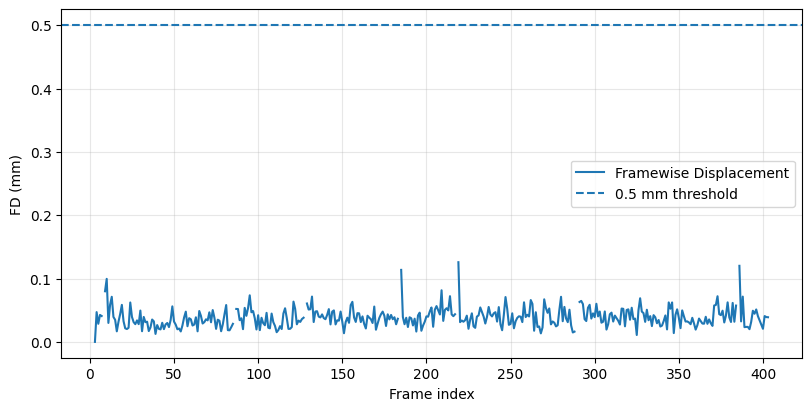

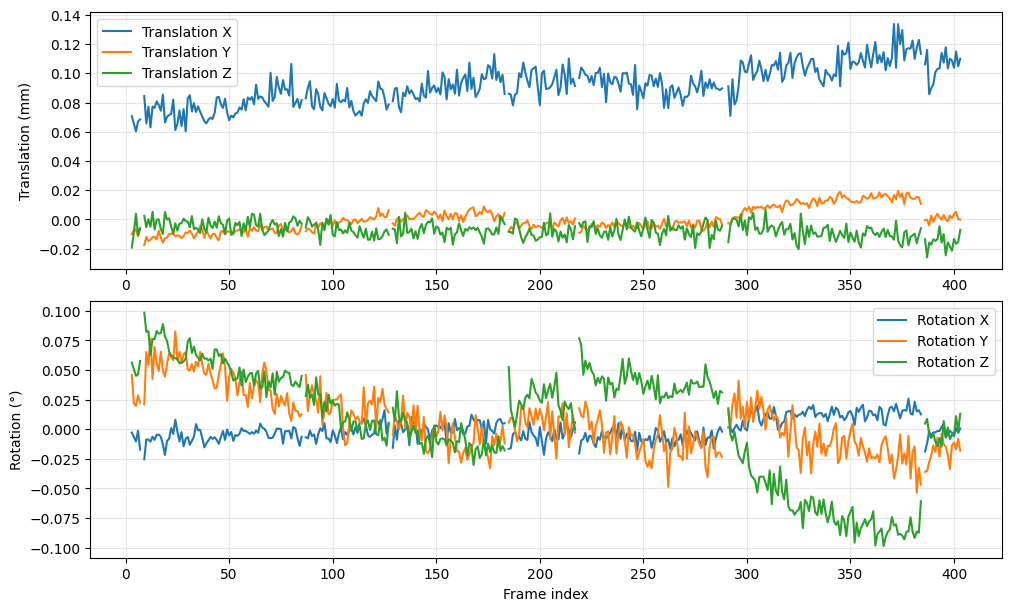

Frames retained after FD censoring: 393 / 404


In [8]:
n_frames = data.shape[-1]

fd = fu.framewise_displacement(rigid, radius_mm=RADIUS_MM)
fd_full = np.full(n_frames, np.nan)
fd_full[kept_idx] = fd

bad_fd = fu.plot_fd(fd_full, FD_THRESH, BASE / "framewise_displacement.png")
fd_tag = f"{FD_THRESH:g}".replace(".", "p")
np.savetxt(BASE / f"fd_over_{fd_tag}_indices.txt", bad_fd, fmt="%d")

skip.update(int(i) for i in bad_fd)

# Drop newly censored frames from the registered outputs
keep_after_all = [i for i in kept_idx if i not in skip]
sel = np.isin(kept_idx, keep_after_all)
reg_use    = reg[..., sel]
rigid_use  = rigid[:, sel]
metric_use = metric[sel]
stop_use   = [s for s, ok in zip(stop, sel) if ok]

# NaN-pad back to full length
reg_full, rigid_full, metric_full, stop_full = fu.reinstate_nans(
    reg_use, rigid_use, metric_use, stop_use, n_frames, keep_after_all,
)

fu.plot_registration_parameters(rigid_full, registration_path / "registration.png")
print(f"Frames retained after FD censoring: {len(keep_after_all)} / {n_frames}")

## Temporal smoothing → save cleaned run

Apply boxcar / Savitzky–Golay (or none), save the cleaned 4D run as
`fusi_run_clean.nii.gz`, and use it as the input for connectivity analysis.

In [9]:
import gc

if SMOOTH_METHOD == "none":
    smoothed = reg_full.copy()
elif SMOOTH_METHOD == "boxcar":
    smoothed = fu.boxcar_smooth(reg_full, SMOOTH_WINDOW)
elif SMOOTH_METHOD == "savgol":
    smoothed = fu.savgol_smooth(reg_full, **SG_PARAMS)
else:
    raise ValueError(f"Unknown SMOOTH_METHOD “{SMOOTH_METHOD}”")

clean_img = nib.Nifti1Image(np.nan_to_num(smoothed), affine)
clean_img.to_filename(BASE / "fusi_run_clean.nii.gz")
fu.save_nifti(clean_img.get_fdata().mean(axis=-1).astype(np.float32), affine,
              BASE / "fusi_run_clean_mean.nii.gz")
del clean_img

# Cast to float32 (~halves memory) and free large intermediates so the rest
# of the connectivity pipeline doesn't blow past available RAM.
data_clean = np.nan_to_num(smoothed, nan=0.0).astype(np.float32, copy=False)
for _v in ("smoothed", "reg", "reg_full", "reg_use", "data"):
    globals().pop(_v, None)
gc.collect()

nx, ny, nz, nt = data_clean.shape
print(f"Clean data shape: {data_clean.shape}, dtype: {data_clean.dtype} "
      f"(~{data_clean.nbytes / 1e9:.2f} GB)")

/Users/clairenastaskin/Documents/Anise/Experiments/fusiproc_utils2.py:343: RuntimeWarning: Mean of empty slice
  out[..., t] = np.nanmean(data[..., lo:hi], axis=3)


Clean data shape: (175, 84, 141, 404), dtype: float32 (~3.35 GB)


## Connectivity-specific preprocessing

Spatial Gaussian smoothing → high-pass filter → demean & mask → unit-length
voxel time-courses (the input to SVD and seed correlation).

In [10]:
# Gaussian spatial smoothing (no smoothing along time). Write directly into a
# pre-allocated float32 output and drop `data_clean` afterwards to keep the
# peak working set close to one full-volume copy.
data_smooth = np.empty_like(data_clean)
gaussian_filter(
    data_clean,
    sigma=(SPATIAL_SIGMA, SPATIAL_SIGMA, SPATIAL_SIGMA, 0),
    output=data_smooth,
)
del data_clean
gc.collect()

# High-pass Butterworth filter, applied zero-phase. filtfilt may upcast to
# float64; cast back to float32 immediately to control memory.
fs      = 1.0 / t_r
nyquist = fs / 2.0
b, a    = butter(HP_ORDER, HP_CUTOFF_HZ / nyquist, btype="high")
data_smooth = filtfilt(b, a, data_smooth, axis=3).astype(np.float32, copy=False)

# Demean per voxel along time, in place
mean_t = data_smooth.mean(axis=3, keepdims=True).astype(np.float32)
data_smooth -= mean_t
del mean_t

# Scrub non-finite values and apply brain mask (in place)
np.nan_to_num(data_smooth, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data_smooth *= mask[..., np.newaxis]

data_norm = data_smooth   # rename, no copy
del data_smooth
gc.collect()

print(f"data_norm shape: {data_norm.shape}, dtype: {data_norm.dtype} "
      f"(~{data_norm.nbytes / 1e9:.2f} GB) | "
      f"high-pass: {HP_CUTOFF_HZ:.4f} Hz (period {1/HP_CUTOFF_HZ:.0f} s)")

data_norm shape: (175, 84, 141, 404), dtype: float32 (~3.35 GB) | high-pass: 0.0167 Hz (period 60 s)


## SVD

Reshape spatial dims to `(n_voxels, nt)` and compute the thin SVD directly.
Columns of `U` are spatial modes, `S` are singular values, rows of `Vt` are
temporal signatures.

In [11]:
# Full thin SVD on the (n_voxels, nt) matrix would materialize a U the same
# size as data_norm. Two cheaper steps instead:
#   1) restrict to in-mask voxels
#   2) SVD via the (nt × nt) Gram matrix X.T @ X (n_voxels >> nt here)

n_voxels  = nx * ny * nz
flat_mask = mask.reshape(-1)
X = data_norm.reshape(n_voxels, nt)[flat_mask]   # (n_in_mask, nt) float32
print(f"In-mask voxels for SVD: {X.shape[0]} / {n_voxels}")

gram = (X.T @ X).astype(np.float64)              # (nt, nt) — small
eigvals, V = np.linalg.eigh(gram)                # ascending order
order   = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
V       = V[:, order].astype(np.float32)
S       = np.sqrt(np.maximum(eigvals, 0)).astype(np.float32)
Vt      = V.T

# U on masked voxels, then scatter back into a full volume for visualization
U_masked  = (X @ V) / (S[np.newaxis, :] + 1e-12)
US_masked = U_masked * S[np.newaxis, :]
del U_masked, gram, X
gc.collect()

US = np.zeros((n_voxels, nt), dtype=np.float32)
US[flat_mask] = US_masked
US_vol = US.reshape(nx, ny, nz, nt)
del US_masked, US
gc.collect()

print(f"Top 5 singular values: {S[:5]}")

In-mask voxels for SVD: 1102145 / 2072700
Top 5 singular values: [30189894.   1724677.1  1073017.6   835166.    671249.2]


## SVD spatial modes

Show the first 16 modes on a middle slice, and save each mode as a NIfTI.

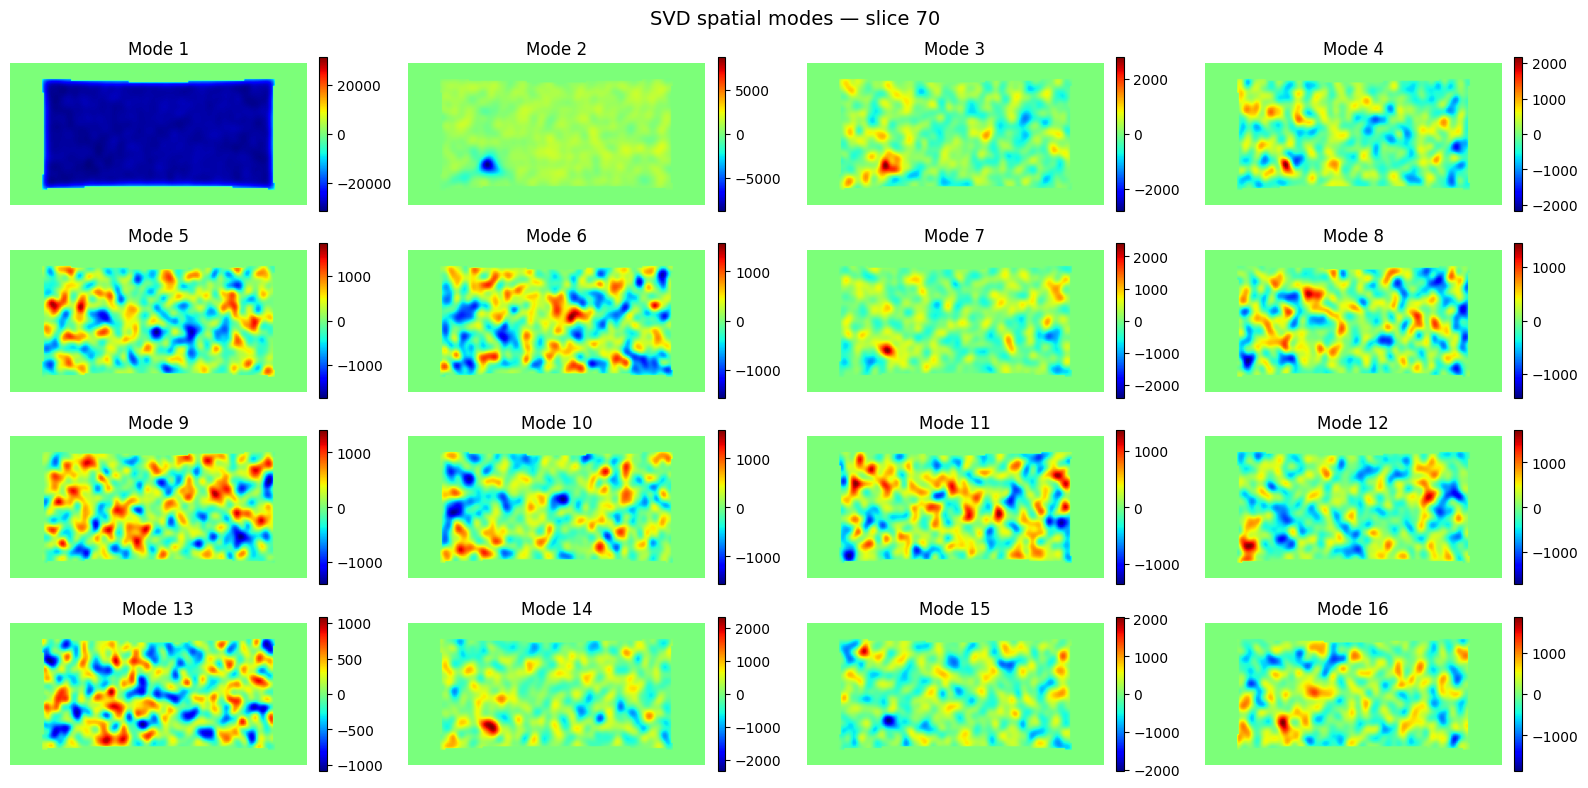

Top 16 SVD modes saved as NIfTI files.


In [12]:
slice_idx = nz // 2
n_modes = 16

fig, axes = plt.subplots(4, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    mode_slice = US_vol[:, :, slice_idx, i]
    vmax = np.max(np.abs(mode_slice))
    im = ax.imshow(mode_slice.T, origin="lower", cmap="jet", vmin=-vmax, vmax=vmax)
    ax.set_title(f"Mode {i + 1}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"SVD spatial modes — slice {slice_idx}", fontsize=14)
plt.tight_layout()
plt.show()

# Save top n_modes as NIfTI volumes
for i in range(n_modes):
    mode_img = nib.Nifti1Image(US_vol[:, :, :, i], affine)
    mode_img.to_filename(BASE / f"svd_mode_{i + 1:02d}.nii.gz")
print(f"Top {n_modes} SVD modes saved as NIfTI files.")

## SVD temporal signatures

Right singular vectors (rows of `Vt`) — the temporal pattern that goes with
each spatial mode.

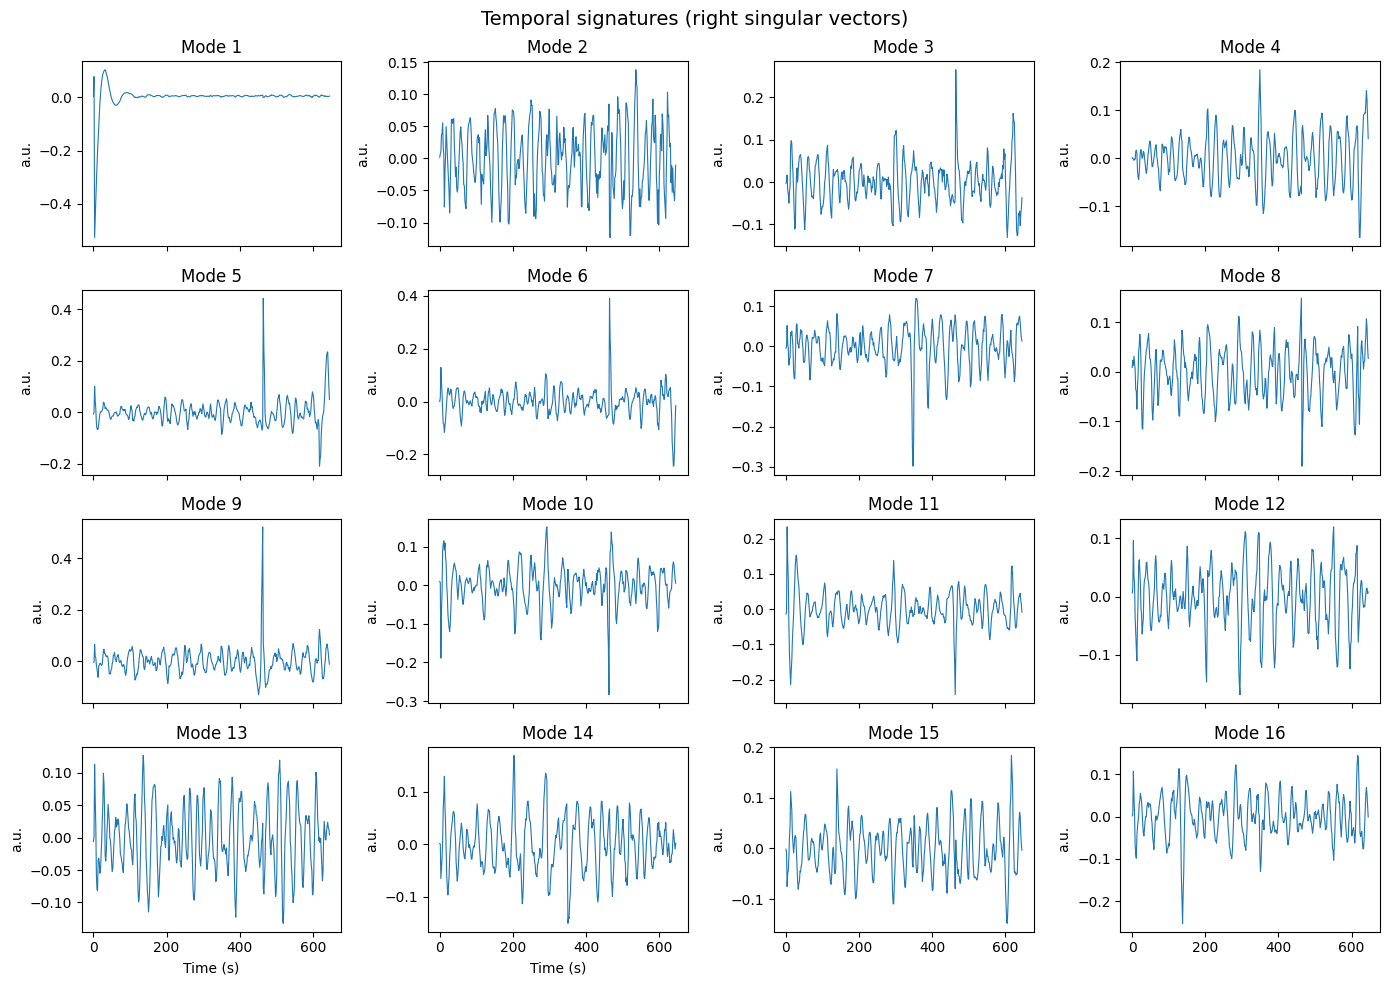

In [13]:
time = np.arange(nt) * t_r

fig, axes = plt.subplots(4, 4, figsize=(14, 10), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(time, Vt[i, :], linewidth=0.8)
    ax.set_title(f"Mode {i + 1}")
    ax.set_ylabel("a.u.")
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Temporal signatures (right singular vectors)", fontsize=14)
plt.tight_layout()
plt.show()

## Seed-based connectivity analysis

Pick a seed voxel (e.g. from a high-z-score location in freeview) and extract
the average time-course over a small cube around it.

Seed time-course shape: (404,)
Saved to: /Users/clairenastaskin/data/sub-Forest001/2026-02-26/deep_individual_digit_069a0d6e-f68d-712b-8000-ca045d6357fa/seed_tc_x93_y33_z12_r2.npy


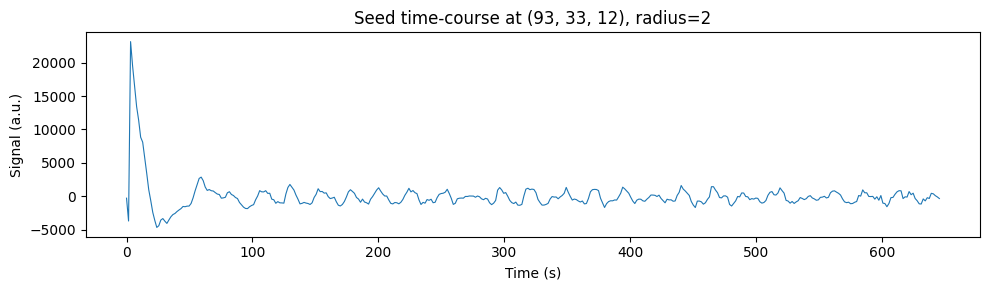

In [14]:
# Seed coordinate (x, y, z) and cube half-side (in voxels)
seed_coord = (93, 33, 12)
radius = 2

x0, y0, z0 = seed_coord
seed_block = data_norm[
    x0 - radius:x0 + radius + 1,
    y0 - radius:y0 + radius + 1,
    z0 - radius:z0 + radius + 1,
    :,
]
seed_tc = seed_block.mean(axis=(0, 1, 2))

seed_tc_path = BASE / f"seed_tc_x{x0}_y{y0}_z{z0}_r{radius}.npy"
np.save(seed_tc_path, seed_tc)
print(f"Seed time-course shape: {seed_tc.shape}")
print(f"Saved to: {seed_tc_path}")

plt.figure(figsize=(10, 3))
plt.plot(np.arange(nt) * t_r, seed_tc, linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Signal (a.u.)")
plt.title(f"Seed time-course at {seed_coord}, radius={radius}")
plt.tight_layout()
plt.show()

## Correlation map

Pearson correlation between the seed time-course and every voxel, computed
as the mean of the product of z-scored time-courses.

In [15]:
# Pearson r without materializing a full-volume z-scored copy.
# data_norm is already demeaned per voxel, so cov(seed, voxel) = ⟨voxel, seed_demean⟩.
seed_demean   = (seed_tc - seed_tc.mean()).astype(np.float32)
seed_norm_val = float(np.linalg.norm(seed_demean))

num         = np.einsum("xyzt,t->xyz", data_norm, seed_demean)   # numerator
voxel_norm  = np.linalg.norm(data_norm, axis=-1)                 # ‖voxel‖
corr_map    = num / (voxel_norm * seed_norm_val + 1e-12)
corr_map    = np.where(mask, corr_map, np.nan)

del num, voxel_norm
gc.collect()

print(f"Correlation map shape: {corr_map.shape}")
print(f"r range (within mask): [{np.nanmin(corr_map):.3f}, {np.nanmax(corr_map):.3f}]")

Correlation map shape: (175, 84, 141)
r range (within mask): [0.660, 0.998]


## Visualize and save the correlation map

Three orthogonal slices through the seed plus a NIfTI on disk.

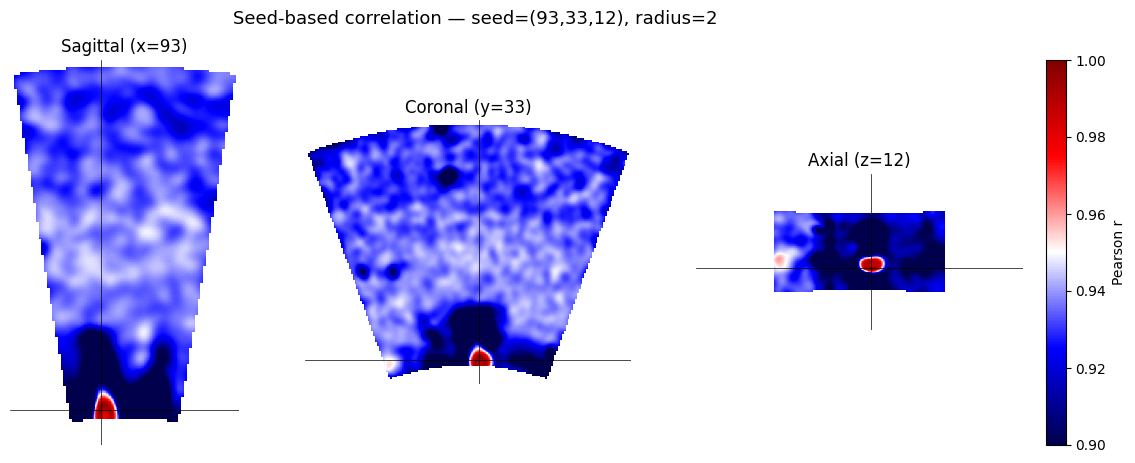

Correlation map saved to: /Users/clairenastaskin/data/sub-Forest001/2026-02-26/deep_individual_digit_069a0d6e-f68d-712b-8000-ca045d6357fa/seed_corr_x93_y33_z12_r2.nii.gz


In [21]:
vmin, vmax = 0.9, 1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(corr_map[x0, :, :].T, origin="lower", cmap="seismic", vmin=vmin, vmax=vmax)
axes[0].axhline(z0, color="k", lw=0.5); axes[0].axvline(y0, color="k", lw=0.5)
axes[0].set_title(f"Sagittal (x={x0})")

axes[1].imshow(corr_map[:, y0, :].T, origin="lower", cmap="seismic", vmin=vmin, vmax=vmax)
axes[1].axhline(z0, color="k", lw=0.5); axes[1].axvline(x0, color="k", lw=0.5)
axes[1].set_title(f"Coronal (y={y0})")

im = axes[2].imshow(corr_map[:, :, z0].T, origin="lower", cmap="seismic", vmin=vmin, vmax=vmax)
axes[2].axhline(y0, color="k", lw=0.5); axes[2].axvline(x0, color="k", lw=0.5)
axes[2].set_title(f"Axial (z={z0})")

for ax in axes:
    ax.axis("off")

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Pearson r")
fig.suptitle(f"Seed-based correlation — seed=({x0},{y0},{z0}), radius={radius}", fontsize=13)
plt.show()

corr_save = np.nan_to_num(corr_map, nan=0.0).astype(np.float32)
corr_img = nib.Nifti1Image(corr_save, affine)
corr_path = BASE / f"seed_corr_x{x0}_y{y0}_z{z0}_r{radius}.nii.gz"
corr_img.to_filename(corr_path)
print(f"Correlation map saved to: {corr_path}")
